<a href="https://colab.research.google.com/github/Hoc04/TrinhThanhHoc/blob/IT24M/machineLearningWeb/TaiLieu/NotebookJupyter/08_dimensionality_reduction_VN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chương 8 – Giảm chiều dữ liệu**

_Cuốn sổ tay này chứa tất cả mã mẫu và giải pháp cho các bài tập trong chương 8._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Thiết lập

Dự án này yêu cầu Python 3.7 trở lên.

In [1]:
import sys

assert sys.version_info >= (3, 7)

Nó cũng yêu cầu Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Như chúng ta đã thực hiện trong các chương trước, hãy định nghĩa các kích thước phông chữ mặc định để làm cho các hình ảnh trở nên đẹp hơn:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Và hãy tạo thư mục images/dim_reduction (nếu nó chưa tồn tại), và định nghĩa hàm save_fig() được sử dụng trong toàn bộ sổ tay này để lưu các hình ảnh với độ phân giải cao cho cuốn sách:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "dim_reduction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# PCA

Chương này bắt đầu bằng một số hình ảnh để giải thích các khái niệm về PCA và N học Đường cong. Dưới đây là mã để tạo ra những hình ảnh này. Bạn có thể bỏ qua trực tiếp phần Thành phần chính bên dưới nếu bạn muốn.

Hãy tạo ra một tập dữ liệu 3D nhỏ. Nó có hình oval, xoay quanh không gian 3D, với các điểm phân bố không đều, và có khá nhiều tiếng ồn:

In [5]:
# extra code

import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * np.random.randn(m, 3)  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

Vẽ tập dữ liệu 3D, với mặt phẳng chiếu.

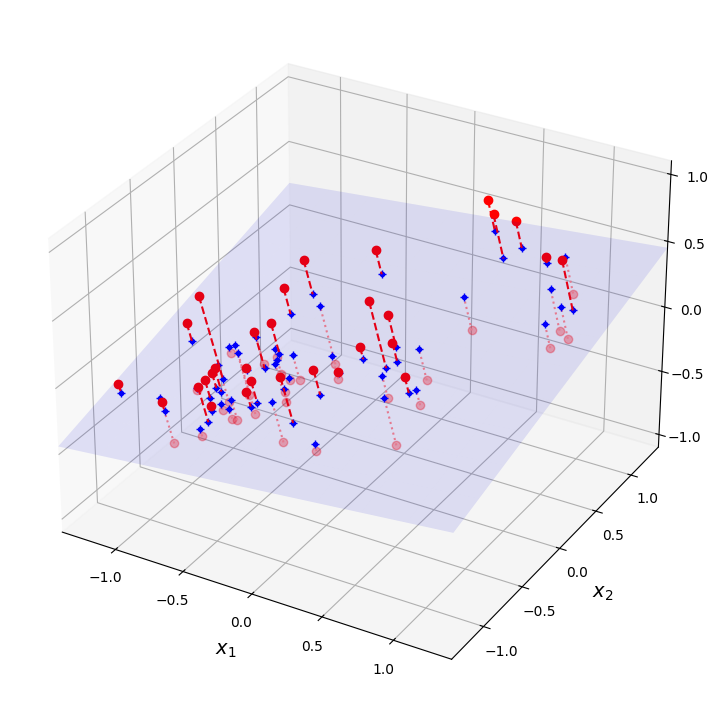

In [6]:
# extra code – this cell generates and saves Figure 8–2

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)  # dataset reduced to 2D
X3D_inv = pca.inverse_transform(X2D)  # 3D position of the projected samples
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

axes = [-1.4, 1.4, -1.4, 1.4, -1.1, 1.1]
x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 10),
                     np.linspace(axes[2], axes[3], 10))
w1, w2 = np.linalg.solve(Vt[:2, :2], Vt[:2, 2])  # projection plane coefs
z = w1 * (x1 - pca.mean_[0]) + w2 * (x2 - pca.mean_[1]) - pca.mean_[2]  # plane
X3D_above = X[X[:, 2] >= X3D_inv[:, 2]]  # samples above plane
X3D_below = X[X[:, 2] < X3D_inv[:, 2]]  # samples below plane

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

# plot samples and projection lines below plane first
ax.plot(X3D_below[:, 0], X3D_below[:, 1], X3D_below[:, 2], "ro", alpha=0.3)
for i in range(m):
    if X[i, 2] < X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], ":", color="#F88")

ax.plot_surface(x1, x2, z, alpha=0.1, color="b")  # projection plane
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b+")  # projected samples
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b.")

# now plot projection lines and samples above plane
for i in range(m):
    if X[i, 2] >= X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], "r--")

ax.plot(X3D_above[:, 0], X3D_above[:, 1], X3D_above[:, 2], "ro")

def set_xyz_axes(ax, axes):
    ax.xaxis.set_rotate_label(False)
    ax.yaxis.set_rotate_label(False)
    ax.zaxis.set_rotate_label(False)
    ax.set_xlabel("$x_1$", labelpad=8, rotation=0)
    ax.set_ylabel("$x_2$", labelpad=8, rotation=0)
    ax.set_zlabel("$x_3$", labelpad=8, rotation=0)
    ax.set_xlim(axes[0:2])
    ax.set_ylim(axes[2:4])
    ax.set_zlim(axes[4:6])

set_xyz_axes(ax, axes)
ax.set_zticks([-1, -0.5, 0, 0.5, 1])

save_fig("dataset_3d_plot", tight_layout=False)
plt.show()

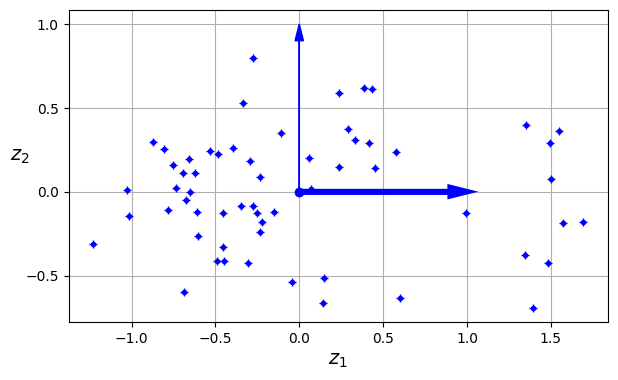

In [7]:
# extra code – this cell generates and saves Figure 8–3

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect='equal')
ax.plot(X2D[:, 0], X2D[:, 1], "b+")
ax.plot(X2D[:, 0], X2D[:, 1], "b.")
ax.plot([0], [0], "bo")
ax.arrow(0, 0, 1, 0, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=4)
ax.arrow(0, 0, 0, 1, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=1)
ax.set_xlabel("$z_1$")
ax.set_yticks([-0.5, 0, 0.5, 1])
ax.set_ylabel("$z_2$", rotation=0)
ax.set_axisbelow(True)
ax.grid(True)
save_fig("dataset_2d_plot")

In [8]:
from sklearn.datasets import make_swiss_roll

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

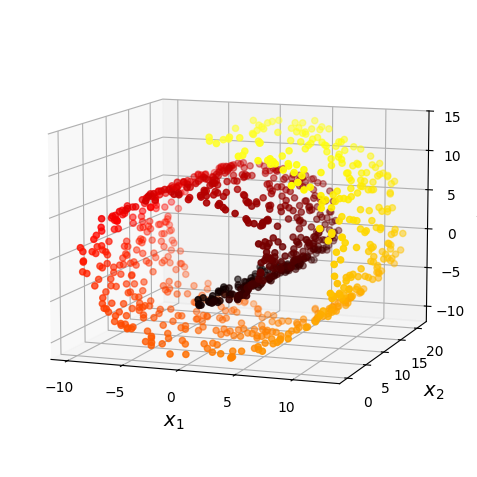

In [9]:
# extra code – this cell generates and saves Figure 8–4

from matplotlib.colors import ListedColormap

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

axes = [-11.5, 14, -2, 23, -12, 15]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap=darker_hot)
ax.view_init(10, -70)
set_xyz_axes(ax, axes)
save_fig("swiss_roll_plot")
plt.show()

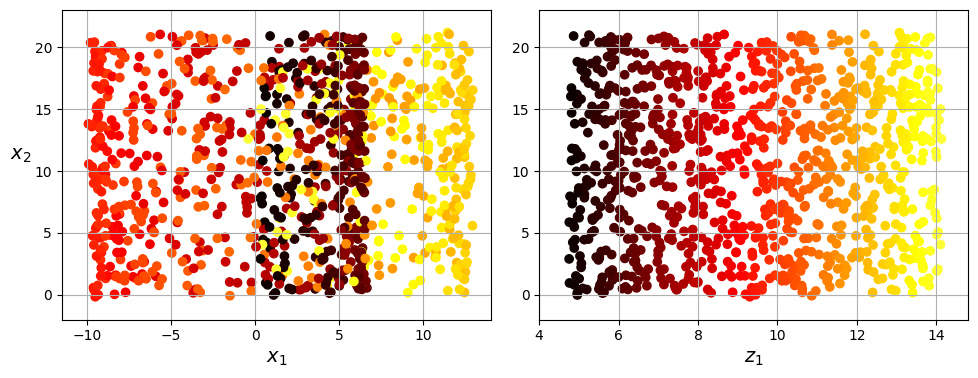

In [10]:
# extra code – this cell generates and saves plots for Figure 8–5

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.scatter(X_swiss[:, 0], X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis(axes[:4])
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", labelpad=10, rotation=0)
plt.grid(True)

plt.subplot(122)
plt.scatter(t, X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis([4, 14.8, axes[2], axes[3]])
plt.xlabel("$z_1$")
plt.grid(True)

save_fig("squished_swiss_roll_plot")
plt.show()

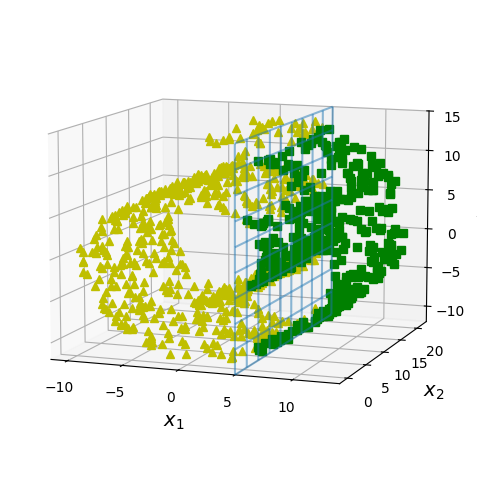

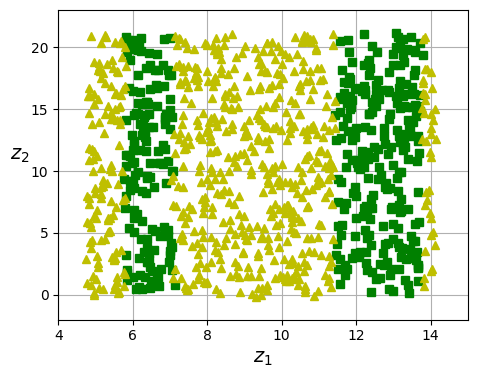

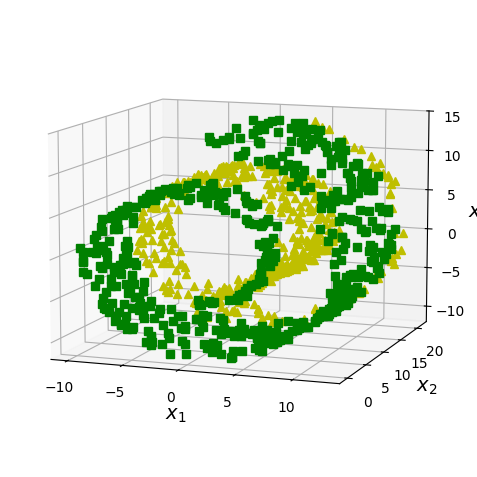

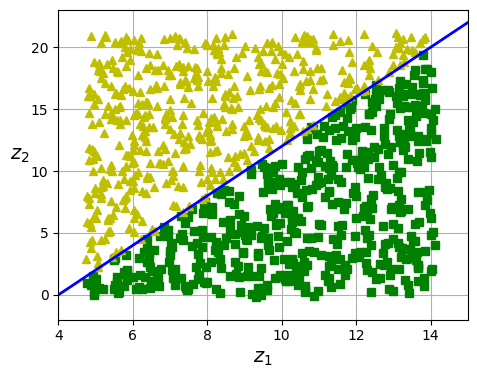

In [11]:
# extra code – this cell generates and saves plots for Figure 8–6

axes = [-11.5, 14, -2, 23, -12, 15]
x2s = np.linspace(axes[2], axes[3], 10)
x3s = np.linspace(axes[4], axes[5], 10)
x2, x3 = np.meshgrid(x2s, x3s)

positive_class = X_swiss[:, 0] > 5
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot_wireframe(5, x2, x3, alpha=0.5)
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
set_xyz_axes(ax, axes)
save_fig("manifold_decision_boundary_plot1")
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
save_fig("manifold_decision_boundary_plot2")
plt.show()

positive_class = 2 * (t[:] - 4) > X_swiss[:, 1]
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel("$x_1$", rotation=0)
ax.set_ylabel("$x_2$", rotation=0)
ax.set_zlabel("$x_3$", rotation=0)
ax.set_xlim(axes[0:2])
ax.set_ylim(axes[2:4])
ax.set_zlim(axes[4:6])
save_fig("manifold_decision_boundary_plot3")
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.plot([4, 15], [0, 22], "b-", linewidth=2)
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
save_fig("manifold_decision_boundary_plot4")
plt.show()

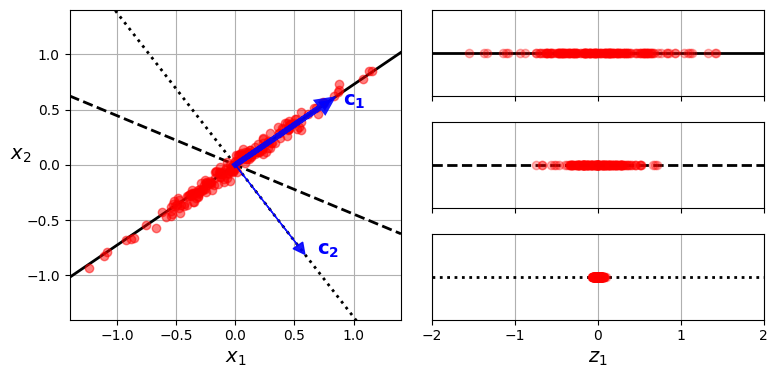

In [12]:
# extra code – this cell generates and saves Figure 8–7

angle = np.pi / 5
stretch = 5
m = 200

np.random.seed(3)
X_line = np.random.randn(m, 2) / 10
X_line = X_line @ np.array([[stretch, 0], [0, 1]])  # stretch
X_line = X_line @ [[np.cos(angle), np.sin(angle)],
                   [np.sin(angle), np.cos(angle)]]  # rotate

u1 = np.array([np.cos(angle), np.sin(angle)])
u2 = np.array([np.cos(angle - 2 * np.pi / 6), np.sin(angle - 2 * np.pi / 6)])
u3 = np.array([np.cos(angle - np.pi / 2), np.sin(angle - np.pi / 2)])

X_proj1 = X_line @ u1.reshape(-1, 1)
X_proj2 = X_line @ u2.reshape(-1, 1)
X_proj3 = X_line @ u3.reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.subplot2grid((3, 2), (0, 0), rowspan=3)
plt.plot([-1.4, 1.4], [-1.4 * u1[1] / u1[0], 1.4 * u1[1] / u1[0]], "k-",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u2[1] / u2[0], 1.4 * u2[1] / u2[0]], "k--",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u3[1] / u3[0], 1.4 * u3[1] / u3[0]], "k:",
         linewidth=2)
plt.plot(X_line[:, 0], X_line[:, 1], "ro", alpha=0.5)
plt.arrow(0, 0, u1[0], u1[1], head_width=0.1, linewidth=4, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.arrow(0, 0, u3[0], u3[1], head_width=0.1, linewidth=1, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.text(u1[0] + 0.1, u1[1] - 0.05, r"$\mathbf{c_1}$", color="blue")
plt.text(u3[0] + 0.1, u3[1], r"$\mathbf{c_2}$", color="blue")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.axis([-1.4, 1.4, -1.4, 1.4])
plt.grid()

plt.subplot2grid((3, 2), (0, 1))
plt.plot([-2, 2], [0, 0], "k-", linewidth=2)
plt.plot(X_proj1[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (1, 1))
plt.plot([-2, 2], [0, 0], "k--", linewidth=2)
plt.plot(X_proj2[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (2, 1))
plt.plot([-2, 2], [0, 0], "k:", linewidth=2)
plt.plot(X_proj3[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.axis([-2, 2, -1, 1])
plt.xlabel("$z_1$")
plt.grid()

save_fig("pca_best_projection_plot")
plt.show()

## Các thành phần chính

In [13]:
import numpy as np

# X = [...]  # the small 3D dataset was created earlier in this notebook
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

Lưu ý: về nguyên tắc, thuật toán phân tích SVD (phân tích giá trị suy biến) trả về ba ma trận, **U**, **$\Sigma$** và **V**, sao cho **$X = U\Sigma V^\intercal$**, trong đó **U** là một ma trận $m \times m$, **$\Sigma$** là một ma trận $m \times n$, và **V** là một ma trận $n \times n$. Nhưng hàm `svd()` lại trả về **U**, **s** và **$V^\intercal$** thay thế. **s** là vectơ chứa tất cả các giá trị trên đường chéo chính của $n$ hàng đầu tiên của **$\Sigma$**. Vì **$\Sigma$** toàn là số không ở các vị trí khác, bạn có thể dễ dàng tái tạo nó từ **s**, như sau:

In [14]:
# extra code – shows how to construct Σ from s
m, n = X.shape
Σ = np.zeros_like(X_centered)
Σ[:n, :n] = np.diag(s)
assert np.allclose(X_centered, U @ Σ @ Vt)

## Chiếu xuống d kích thước

In [15]:
W2 = Vt[:2].T
X2D = X_centered @ W2

## Dùng Scikit-Learn

Với Scikit-Learn, PCA thực sự rất đơn giản. Nó thậm chí còn tự động xử lý việc trung tâm hóa trung bình cho bạn:

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

In [17]:
pca.components_

array([[ 0.67857588,  0.70073508,  0.22023881],
       [ 0.72817329, -0.6811147 , -0.07646185]])

## Tỷ lệ phương sai giải thích

Bây giờ hãy xem xét tỷ lệ phương sai được giải thích:

In [18]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

Chiều thứ nhất giải thích khoảng 76% sự biến thiên, trong khi chiều thứ hai giải thích khoảng 15%.

Khi giảm xuống 2D, chúng ta đã mất khoảng 9% sự biến thiên:

In [19]:
1 - pca.explained_variance_ratio_.sum()  # extra code

np.float64(0.09028309326742057)

## Chọn Số Kích Thước Phù Hợp.

In [20]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1  # d equals 154

Lưu ý: Tôi đã thêm `parser="auto"` khi gọi `fetch_openml()` để tránh một cảnh báo về việc giá trị mặc định cho tham số đó sẽ thay đổi trong tương lai (điều này không liên quan trong trường hợp này). Vui lòng xem [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html) để biết thêm chi tiết.

In [21]:
d

np.int64(154)

In [22]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

In [23]:
pca.n_components_

np.int64(154)

In [24]:
pca.explained_variance_ratio_.sum()  # extra code

np.float64(0.9501960192613031)

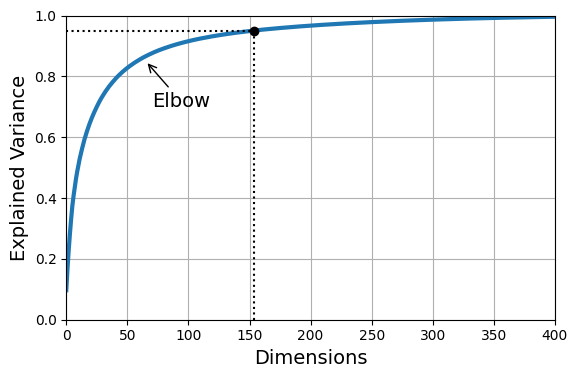

In [25]:
# extra code – this cell generates and saves Figure 8–8

plt.figure(figsize=(6, 4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True)
save_fig("explained_variance_plot")
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       6...
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       492, 493, 494, 495, 496, 497, 498, 499])},
                   random_state=42)

In [27]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


In [28]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

clf = make_pipeline(PCA(random_state=42), SGDClassifier())
param_grid = {"pca__n_components": np.arange(10, 80)}
grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X_train[:1000], y_train[:1000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                       ('sgdclassifier', SGDClassifier())]),
             param_grid={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79])})

In [29]:
grid_search.best_params_

{'pca__n_components': np.int64(67)}

## PCA cho Nén Dữ Liệu

In [30]:
pca = PCA(0.95)
X_reduced = pca.fit_transform(X_train, y_train)

In [31]:
X_recovered = pca.inverse_transform(X_reduced)

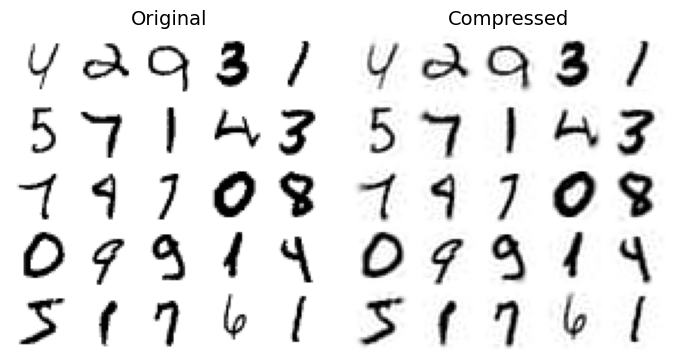

In [32]:
# extra code – this cell generates and saves Figure 8–9

plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")

save_fig("mnist_compression_plot")

## PCA ngẫu nhiên

In [33]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

## PCA gia tăng

In [34]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

**Sử dụng lớp memmap của NumPy – một ánh xạ bộ nhớ tới một mảng được lưu trữ trong một tệp nhị phân trên đĩa.**

Hãy tạo một thể hiện memmap, sao chép tập dữ liệu huấn luyện MNIST vào đó và gọi flush(), điều này đảm bảo rằng bất kỳ dữ liệu nào vẫn còn trong bộ nhớ đệm sẽ được lưu vào đĩa. Điều này thường được thực hiện bởi một chương trình đầu tiên:

In [35]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train  # could be a loop instead, saving the data chunk by chunk
X_mmap.flush()

Tiếp theo, một chương trình khác sẽ tải dữ liệu và sử dụng nó để đào tạo.

In [36]:
X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

IncrementalPCA(batch_size=600, n_components=154)

# Chiếu ngẫu nhiên

**Cảnh báo:** phần này sẽ sử dụng khoảng 2.5 GB RAM. Nếu máy tính của bạn hết bộ nhớ, chỉ cần giảm m và n.

In [37]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, ε = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=ε)
d

np.int64(7300)

In [38]:
# extra code – show the equation computed by johnson_lindenstrauss_min_dim
d = int(4 * np.log(m) / (ε ** 2 / 2 - ε ** 3 / 3))
d

7300

In [39]:
n = 20_000
np.random.seed(42)
P = np.random.randn(d, n) / np.sqrt(d)  # std dev = square root of variance

X = np.random.randn(m, n)  # generate a fake dataset
X_reduced = X @ P.T

In [40]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=ε, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)  # same result as above

Cảnh báo, ô dưới đây có thể mất vài phút để chạy.

In [41]:
components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

In [42]:
# extra code – performance comparison between Gaussian and Sparse RP

from sklearn.random_projection import SparseRandomProjection

print("GaussianRandomProjection fit")
%timeit GaussianRandomProjection(random_state=42).fit(X)
print("SparseRandomProjection fit")
%timeit SparseRandomProjection(random_state=42).fit(X)

gaussian_rnd_proj = GaussianRandomProjection(random_state=42).fit(X)
sparse_rnd_proj = SparseRandomProjection(random_state=42).fit(X)
print("GaussianRandomProjection transform")
%timeit gaussian_rnd_proj.transform(X)
print("SparseRandomProjection transform")
%timeit sparse_rnd_proj.transform(X)

GaussianRandomProjection fit
4.85 s ± 372 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjection fit
3.7 s ± 544 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
GaussianRandomProjection transform
42 s ± 152 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjection transform
5.64 s ± 244 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# LLE

In [43]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit_transform(X_swiss)

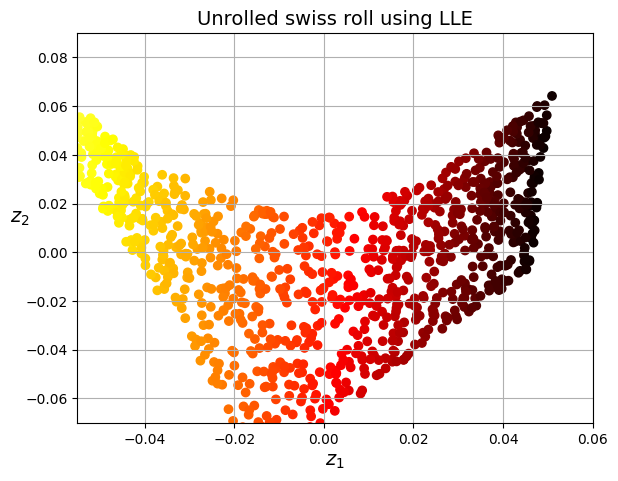

In [44]:
# extra code – this cell generates and saves Figure 8–10

plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1],
            c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
plt.axis([-0.055, 0.060, -0.070, 0.090])
plt.grid(True)

save_fig("lle_unrolling_plot")
plt.title("Unrolled swiss roll using LLE")
plt.show()

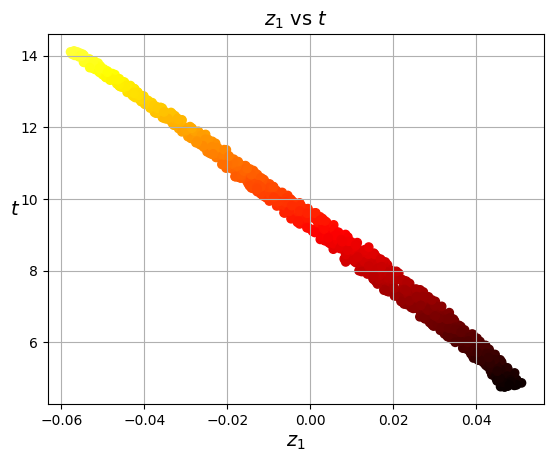

In [45]:
# extra code – shows how well correlated z1 is to t: LLE worked fine
plt.title("$z_1$ vs $t$")
plt.scatter(X_unrolled[:, 0], t, c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$t$", rotation=0)
plt.grid(True)
plt.show()

Lưu ý: Tôi đã thêm `normalized_stress=False` bên dưới để tránh một cảnh báo về việc giá trị mặc định cho siêu tham số đó sẽ thay đổi trong tương lai. Vui lòng xem [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html) để biết thêm chi tiết.

In [46]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, normalized_stress=False, random_state=42)
X_reduced_mds = mds.fit_transform(X_swiss)

In [47]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X_swiss)

In [48]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
X_reduced_tsne = tsne.fit_transform(X_swiss)

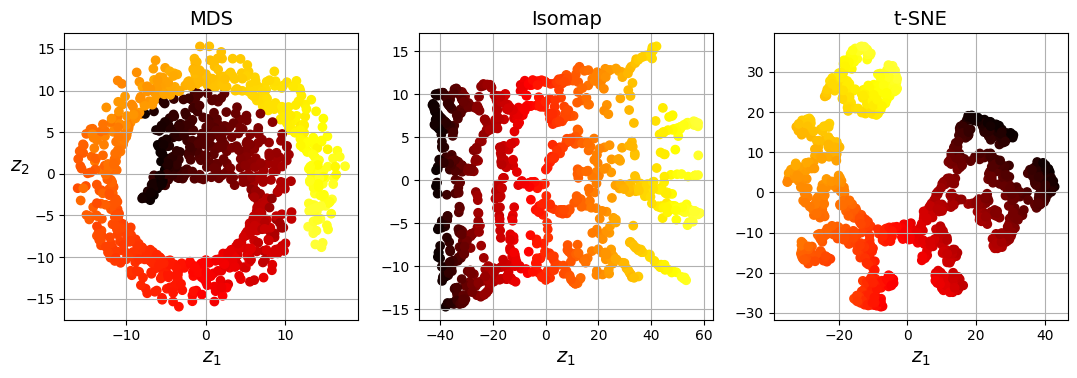

In [49]:
# extra code – this cell generates and saves Figure 8–11

titles = ["MDS", "Isomap", "t-SNE"]

plt.figure(figsize=(11, 4))

for subplot, title, X_reduced in zip((131, 132, 133), titles,
                                     (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if subplot == 131:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid(True)

save_fig("other_dim_reduction_plot")
plt.show()

# Tài liệu bổ sung – Kernel PCA

In [50]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.04, random_state=42)
X_reduced = rbf_pca.fit_transform(X_swiss)

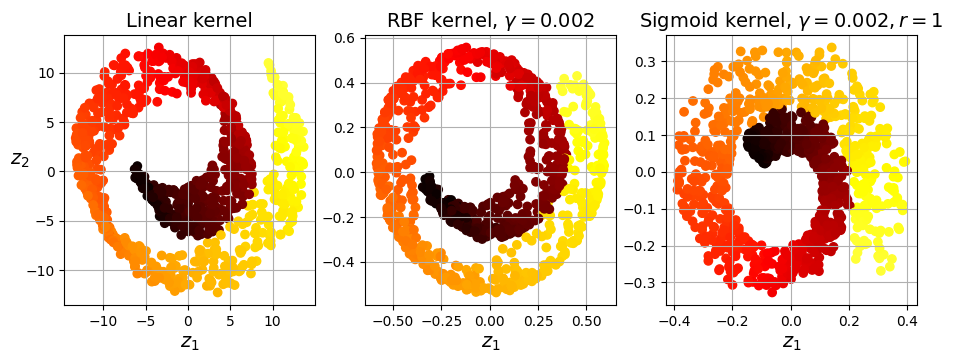

In [51]:
lin_pca = KernelPCA(kernel="linear")
rbf_pca = KernelPCA(kernel="rbf", gamma=0.002)
sig_pca = KernelPCA(kernel="sigmoid", gamma=0.002, coef0=1)

kernel_pcas = ((lin_pca, "Linear kernel"),
               (rbf_pca, rf"RBF kernel, $\gamma={rbf_pca.gamma}$"),
               (sig_pca, rf"Sigmoid kernel, $\gamma={sig_pca.gamma}, r={sig_pca.coef0}$"))

plt.figure(figsize=(11, 3.5))
for idx, (kpca, title) in enumerate(kernel_pcas):
    kpca.n_components = 2
    kpca.random_state = 42
    X_reduced = kpca.fit_transform(X_swiss)

    plt.subplot(1, 3, idx + 1)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if idx == 0:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid()

plt.show()

# Bài tập

<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 1: Động lực chính để giảm chiều dữ liệu là gì? Những hạn chế chính là gì?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 2: Lời nguyền của số chiều là gì?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 3: Một khi chiều của tập dữ liệu đã được giảm, có thể đảo ngược thao tác không? Nếu có, bằng cách nào? Nếu không, tại sao?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 4: PCA có thể được sử dụng để giảm chiều của một tập dữ liệu phi tuyến tính cao không?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 5: Giả sử bạn thực hiện PCA trên một tập dữ liệu 1.000 chiều, đặt tỷ lệ phương sai giải thích là 95%. Tập dữ liệu kết quả sẽ có bao nhiêu chiều?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 6: Trong những trường hợp nào bạn sẽ sử dụng PCA thông thường, PCA tăng dần, PCA ngẫu nhiên, hoặc phép chiếu ngẫu nhiên?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 7: Làm thế nào bạn có thể đánh giá hiệu suất của một thuật toán giảm chiều trên tập dữ liệu của bạn?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 8: Có ý nghĩa gì khi nối chuỗi hai thuật toán giảm chiều khác nhau không?</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 9: Đánh giá tác động của PCA đối với Rừng ngẫu nhiên và SGDClassifier</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 10: Trực quan hóa tập dữ liệu MNIST bằng t-SNE và So sánh thuật toán</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Hãy phân tích kỹ các khái niệm trong bài học và áp dụng vào yêu cầu của đề bài. Đọc lại phần lý thuyết liên quan nếu cần.</p>
  </div>
</div>
